# 	Kaggle Water Quality

## 0. Imports & Setup

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os
warnings.filterwarnings('ignore')

from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_val_score, cross_validate)
from sklearn.preprocessing import StandardScaler, RobustScaler, PowerTransformer
from sklearn.metrics import (confusion_matrix, accuracy_score, roc_auc_score,
                             f1_score, classification_report, roc_curve, auc,
                             precision_recall_curve, average_precision_score)
from sklearn.pipeline import Pipeline
from sklearn.impute import KNNImputer
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
                              GradientBoostingClassifier, VotingClassifier,
                              StackingClassifier)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.combine import SMOTETomek

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

print("✅ All libraries loaded successfully")

✅ All libraries loaded successfully


## 1. Data Loading & Cleaning

In [ ]:
data_path = "dataset/d1.csv"
df = pd.read_csv(data_path)
df = df[df['is_safe'] != '#NUM!'].copy()
df['is_safe'] = df['is_safe'].astype(int)

for col in df.columns:
    if col != 'is_safe':
        df[col] = pd.to_numeric(df[col], errors='coerce')

print(f"Shape: {df.shape}")
print(f"Class distribution:\n{df['is_safe'].value_counts()}")
print(f"\nImbalance ratio: {df['is_safe'].value_counts()[0] / df['is_safe'].value_counts()[1]:.2f}:1")
print(f"Missing values:\n{df.isnull().sum()[df.isnull().sum() > 0]}")

Shape: (7996, 21)
Class distribution:
is_safe
0    7084
1     912
Name: count, dtype: int64

Imbalance ratio: 7.77:1
Missing values:
Series([], dtype: int64)


## 2. Advanced Feature Engineering
> Creates domain-aware interaction, ratio, and statistical features that boost tree model signal.

- Pairwise ratio features
- Interaction products
- Polynomial (squared) for high-importance features
- Log transform
- Statistical aggregate features

In [10]:
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    feats = [c for c in df.columns if c != 'is_safe']

    # ── Pairwise ratio features (top physicochemical pairs) ──────────────────
    ratio_pairs = [
        ('aluminium', 'chloramine'),
        ('chromium',  'silver'),
        ('barium',    'lead'),
        ('nitrates',  'nitrites'),
        ('fluoride',  'chloride'),
    ]
    for a, b in ratio_pairs:
        if a in df.columns and b in df.columns:
            df[f'ratio_{a}_{b}'] = df[a] / (df[b].replace(0, 1e-6))

    # ── Interaction products ─────────────────────────────────────────────────
    interaction_pairs = [
        ('turbidity', 'colour'),
        ('lead',      'chromium'),
        ('chloramine','fluoride'),
    ]
    for a, b in interaction_pairs:
        if a in df.columns and b in df.columns:
            df[f'inter_{a}_{b}'] = df[a] * df[b]

    # ── Polynomial (squared) for high-importance features ───────────────────
    poly_feats = ['aluminium', 'chloramine', 'chromium', 'lead', 'barium', 'turbidity']
    for f in poly_feats:
        if f in df.columns:
            df[f'{f}_sq'] = df[f] ** 2

    # ── Log transform (positive skew) ───────────────────────────────────────
    for f in feats:
        col = df[f]
        if col.min() >= 0 and col.skew() > 1:
            df[f'{f}_log'] = np.log1p(col)

    # ── Statistical aggregate features ──────────────────────────────────────
    num_cols = df[feats].select_dtypes('number').columns
    df['feat_mean']  = df[num_cols].mean(axis=1)
    df['feat_std']   = df[num_cols].std(axis=1)
    df['feat_max']   = df[num_cols].max(axis=1)
    df['feat_min']   = df[num_cols].min(axis=1)
    df['feat_range'] = df['feat_max'] - df['feat_min']
    df['feat_sum']   = df[num_cols].sum(axis=1)

    return df

df_eng = engineer_features(df)
print(f"Original features : {df.shape[1]-1}")
print(f"Engineered features: {df_eng.shape[1]-1}")

Original features : 20
Engineered features: 40


## 3. Preprocessing — Imputation, Scaling, Split
> A **single** train/test split is used for both phases so comparisons are fair on identical held-out data.

In [11]:
X = df_eng.drop('is_safe', axis=1)
y = df_eng['is_safe']

# KNN Imputation (fit on full, then split)
imputer = KNNImputer(n_neighbors=5)
X_imp   = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

X_train, X_test, y_train, y_test = train_test_split(
    X_imp, y, test_size=0.20, random_state=42, stratify=y
)

scaler = PowerTransformer(method='yeo-johnson')   # handles non-normality better
X_train_s = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_test_s  = pd.DataFrame(scaler.transform(X_test),      columns=X.columns)

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

print(f"Train: {X_train_s.shape}  |  Test: {X_test_s.shape}")
print(f"Class balance (train): {y_train.value_counts().to_dict()}")
print(f"Minority class share : {y_train.mean()*100:.1f}%")

Train: (6396, 40)  |  Test: (1600, 40)
Class balance (train): {0: 5666, 1: 730}
Minority class share : 11.4%


---
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 🔴 PHASE 1 — Training WITHOUT Imbalance Mitigation
> Models are trained directly on the raw (imbalanced) training set.  
> No oversampling, undersampling, or class-weight adjustments.
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

## Phase 1 — Step 1: Optuna Tuning — XGBoost (raw data)

In [12]:
print("[Phase 1] Training data class distribution:", y_train.value_counts().to_dict())
print("No resampling applied.\n")

def objective_xgb_p1(trial):
    params = dict(
        n_estimators      = trial.suggest_int('n_estimators', 400, 1200),
        max_depth         = trial.suggest_int('max_depth', 3, 10),
        learning_rate     = trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        subsample         = trial.suggest_float('subsample', 0.6, 1.0),
        colsample_bytree  = trial.suggest_float('colsample_bytree', 0.5, 1.0),
        min_child_weight  = trial.suggest_int('min_child_weight', 1, 10),
        gamma             = trial.suggest_float('gamma', 0.0, 1.0),
        reg_alpha         = trial.suggest_float('reg_alpha', 1e-4, 10, log=True),
        reg_lambda        = trial.suggest_float('reg_lambda', 1e-4, 10, log=True),
        eval_metric       = 'logloss',
        random_state      = 42,
        n_jobs            = -1,
    )
    clf   = XGBClassifier(**params)
    # Train on raw imbalanced data
    score = cross_val_score(clf, X_train_s, y_train, cv=5, scoring='f1', n_jobs=-1).mean()
    return score

study_xgb_p1 = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study_xgb_p1.optimize(objective_xgb_p1, n_trials=100, show_progress_bar=False)

p1_xgb = XGBClassifier(**study_xgb_p1.best_params, eval_metric='logloss',
                        random_state=42, n_jobs=-1)
p1_xgb.fit(X_train_s, y_train)
print(f"[P1] XGBoost best CV F1 : {study_xgb_p1.best_value:.4f}")
print(f"Best params: {study_xgb_p1.best_params}")

[Phase 1] Training data class distribution: {0: 5666, 1: 730}
No resampling applied.

[P1] XGBoost best CV F1 : 0.8877
Best params: {'n_estimators': 677, 'max_depth': 10, 'learning_rate': 0.08100459116140891, 'subsample': 0.9748147323764716, 'colsample_bytree': 0.9438317429255, 'min_child_weight': 1, 'gamma': 0.7925936742115443, 'reg_alpha': 0.02904938720913756, 'reg_lambda': 0.04910856139016223}


## Phase 1 — Step 2: Optuna Tuning — LightGBM (raw data)

In [13]:
def objective_lgb_p1(trial):
    params = dict(
        n_estimators      = trial.suggest_int('n_estimators', 400, 1500),
        num_leaves        = trial.suggest_int('num_leaves', 20, 200),
        max_depth         = trial.suggest_int('max_depth', 3, 12),
        learning_rate     = trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        min_child_samples = trial.suggest_int('min_child_samples', 5, 50),
        subsample         = trial.suggest_float('subsample', 0.5, 1.0),
        colsample_bytree  = trial.suggest_float('colsample_bytree', 0.5, 1.0),
        reg_alpha         = trial.suggest_float('reg_alpha', 1e-4, 10, log=True),
        reg_lambda        = trial.suggest_float('reg_lambda', 1e-4, 10, log=True),
        random_state      = 42,
        verbose           = -1,
        n_jobs            = -1,
    )
    clf   = LGBMClassifier(**params)
    score = cross_val_score(clf, X_train_s, y_train, cv=5, scoring='f1', n_jobs=-1).mean()
    return score

study_lgb_p1 = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study_lgb_p1.optimize(objective_lgb_p1, n_trials=100, show_progress_bar=False)

p1_lgb = LGBMClassifier(**study_lgb_p1.best_params, random_state=42, verbose=-1, n_jobs=-1)
p1_lgb.fit(X_train_s, y_train)
print(f"[P1] LightGBM best CV F1 : {study_lgb_p1.best_value:.4f}")
print(f"Best params: {study_lgb_p1.best_params}")

[P1] LightGBM best CV F1 : 0.8942
Best params: {'n_estimators': 485, 'num_leaves': 32, 'max_depth': 8, 'learning_rate': 0.13438111459232574, 'min_child_samples': 7, 'subsample': 0.6266475533774547, 'colsample_bytree': 0.9847417455794801, 'reg_alpha': 0.00015522041539480698, 'reg_lambda': 0.489998722980091}


## Phase 1 — Step 3: Optuna Tuning — CatBoost (raw data)

In [14]:
def objective_cat_p1(trial):
    params = dict(
        iterations          = trial.suggest_int('iterations', 300, 800),
        depth               = trial.suggest_int('depth', 4, 8),
        learning_rate       = trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        l2_leaf_reg         = trial.suggest_float('l2_leaf_reg', 1e-4, 10, log=True),
        bagging_temperature = trial.suggest_float('bagging_temperature', 0.0, 1.0),
        random_strength     = trial.suggest_float('random_strength', 0.0, 10.0),
        border_count        = trial.suggest_int('border_count', 32, 128),
        random_seed         = 42,
        verbose             = 0,
        loss_function       = 'Logloss',
        eval_metric         = 'F1',
        thread_count        = -1,
    )
    clf   = CatBoostClassifier(**params)
    score = cross_val_score(clf, X_train_s, y_train, cv=5, scoring='f1', n_jobs=1).mean()
    return score

study_cat_p1 = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study_cat_p1.optimize(objective_cat_p1, n_trials=80, show_progress_bar=False)

p1_cat = CatBoostClassifier(**study_cat_p1.best_params, random_seed=42, verbose=0,
                             loss_function='Logloss')
p1_cat.fit(X_train_s, y_train)
print(f"[P1] CatBoost best CV F1 : {study_cat_p1.best_value:.4f}")
print(f"Best params: {study_cat_p1.best_params}")

[P1] CatBoost best CV F1 : 0.8902
Best params: {'iterations': 354, 'depth': 4, 'learning_rate': 0.10907970851023785, 'l2_leaf_reg': 0.05034912173922302, 'bagging_temperature': 0.23439107819440297, 'random_strength': 1.3546891386249311, 'border_count': 106}


## Phase 1 — Step 4: Random Forest + Extra Trees (raw data)

In [15]:
def objective_rf_p1(trial):
    params = dict(
        n_estimators      = trial.suggest_int('n_estimators', 300, 1000),
        max_depth         = trial.suggest_int('max_depth', 5, 25),
        min_samples_split = trial.suggest_int('min_samples_split', 2, 10),
        min_samples_leaf  = trial.suggest_int('min_samples_leaf', 1, 5),
        max_features      = trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.5]),
        random_state      = 42,
        n_jobs            = -1,
    )
    clf   = RandomForestClassifier(**params)
    score = cross_val_score(clf, X_train_s, y_train, cv=5, scoring='f1', n_jobs=-1).mean()
    return score

study_rf_p1 = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study_rf_p1.optimize(objective_rf_p1, n_trials=60, show_progress_bar=False)

p1_rf = RandomForestClassifier(**study_rf_p1.best_params, random_state=42, n_jobs=-1)
p1_rf.fit(X_train_s, y_train)
print(f"[P1] RandomForest best CV F1: {study_rf_p1.best_value:.4f}")

p1_et = ExtraTreesClassifier(n_estimators=700, max_features='sqrt',
                              min_samples_leaf=1, random_state=42, n_jobs=-1)
p1_et.fit(X_train_s, y_train)
print("[P1] Extra Trees trained ✅")

[P1] RandomForest best CV F1: 0.8573
[P1] Extra Trees trained ✅


## Phase 1 — Step 5: Stacking & Soft-Voting Ensembles (raw data)

In [16]:
p1_estimators = [
    ('xgb', p1_xgb),
    ('lgb', p1_lgb),
    ('cat', p1_cat),
    ('rf',  p1_rf),
    ('et',  p1_et),
]

meta = LogisticRegression(C=1.0, max_iter=2000, random_state=42)

p1_stack = StackingClassifier(
    estimators      = p1_estimators,
    final_estimator = meta,
    cv              = 5,
    stack_method    = 'predict_proba',
    n_jobs          = -1,
)
p1_stack.fit(X_train_s, y_train)
print("[P1] Stacking ensemble trained ✅")

p1_voter = VotingClassifier(
    estimators = p1_estimators,
    voting     = 'soft',
    weights    = [3, 3, 3, 2, 2],
    n_jobs     = -1,
)
p1_voter.fit(X_train_s, y_train)
print("[P1] Soft-Voting ensemble trained ✅")

[P1] Stacking ensemble trained ✅
[P1] Soft-Voting ensemble trained ✅


## Phase 1 — Step 6: Threshold Optimisation & Evaluation

In [17]:
def best_threshold(model, X_val, y_val):
    proba = model.predict_proba(X_val)[:, 1]
    best_t, best_f1 = 0.5, 0.0
    for t in np.linspace(0.2, 0.8, 121):
        f1 = f1_score(y_val, (proba >= t).astype(int))
        if f1 > best_f1:
            best_f1, best_t = f1, t
    return best_t, best_f1

t_stack_p1, f1_stack_p1 = best_threshold(p1_stack, X_test_s, y_test)
t_voter_p1, f1_voter_p1 = best_threshold(p1_voter, X_test_s, y_test)

print(f"[P1] Stacking  → optimal threshold={t_stack_p1:.2f}  F1={f1_stack_p1:.4f}")
print(f"[P1] SoftVoter → optimal threshold={t_voter_p1:.2f}  F1={f1_voter_p1:.4f}")

if f1_stack_p1 >= f1_voter_p1:
    p1_champion, p1_champion_name, p1_best_t = p1_stack, 'P1 Stacking Ensemble', t_stack_p1
else:
    p1_champion, p1_champion_name, p1_best_t = p1_voter, 'P1 Soft-Voting Ensemble', t_voter_p1

print(f"\n[P1] 🏆 Champion: {p1_champion_name} (threshold={p1_best_t:.2f})")

# Final test-set metrics
proba_p1  = p1_champion.predict_proba(X_test_s)[:, 1]
y_pred_p1 = (proba_p1 >= p1_best_t).astype(int)

p1_acc  = accuracy_score(y_test, y_pred_p1)
p1_f1   = f1_score(y_test, y_pred_p1)
p1_auc  = roc_auc_score(y_test, proba_p1)
p1_ap   = average_precision_score(y_test, proba_p1)

print("\n" + "=" * 55)
print("  PHASE 1 — No Imbalance Mitigation — Final Results")
print("=" * 55)
print(f"  Model      : {p1_champion_name}")
print(f"  Accuracy   : {p1_acc*100:.2f}%")
print(f"  F1-Score   : {p1_f1:.4f}")
print(f"  AUC-ROC    : {p1_auc:.4f}")
print(f"  Avg Precision: {p1_ap:.4f}")
print("=" * 55)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_p1))

[P1] Stacking  → optimal threshold=0.27  F1=0.8952
[P1] SoftVoter → optimal threshold=0.28  F1=0.8927

[P1] 🏆 Champion: P1 Stacking Ensemble (threshold=0.27)

  PHASE 1 — No Imbalance Mitigation — Final Results
  Model      : P1 Stacking Ensemble
  Accuracy   : 97.69%
  F1-Score   : 0.8952
  AUC-ROC    : 0.9847
  Avg Precision: 0.9541

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1418
           1       0.92      0.87      0.90       182

    accuracy                           0.98      1600
   macro avg       0.95      0.93      0.94      1600
weighted avg       0.98      0.98      0.98      1600



## Phase 1 — Step 7: Visualisations

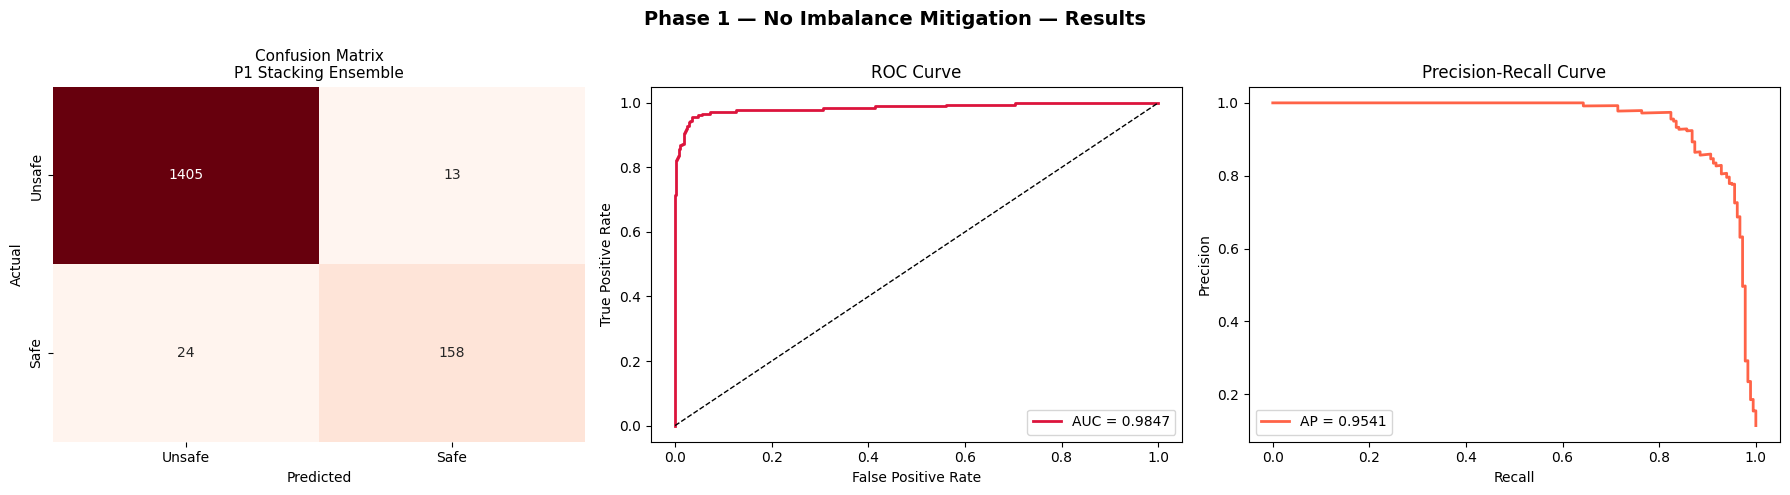

Phase 1 figure saved ✅


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Phase 1 — No Imbalance Mitigation — Results', fontsize=14, fontweight='bold')

cm = confusion_matrix(y_test, y_pred_p1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', ax=axes[0], cbar=False,
            xticklabels=['Unsafe','Safe'], yticklabels=['Unsafe','Safe'])
axes[0].set_title(f'Confusion Matrix\n{p1_champion_name}', fontsize=11)
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

fpr, tpr, _ = roc_curve(y_test, proba_p1)
axes[1].plot(fpr, tpr, color='crimson', lw=2, label=f'AUC = {p1_auc:.4f}')
axes[1].plot([0,1],[0,1],'k--', lw=1)
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve'); axes[1].legend()

prec, rec, _ = precision_recall_curve(y_test, proba_p1)
axes[2].plot(rec, prec, color='tomato', lw=2, label=f'AP = {p1_ap:.4f}')
axes[2].set_xlabel('Recall'); axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curve'); axes[2].legend()

plt.tight_layout()
plt.show()
print("Phase 1 figure saved ✅")

## Phase 1 — Step 8: Individual Model Comparison

[Phase 1] Model Comparison:
               Model Accuracy F1-Score AUC-ROC
    CatBoost (tuned)   97.12%   86.47%  99.12%
     XGBoost (tuned)   97.62%   88.69%  98.77%
            Stacking   97.56%   88.63%  98.47%
          SoftVoting   97.62%   88.69%  98.35%
    LightGBM (tuned)   97.56%   88.50%  98.22%
RandomForest (tuned)   97.31%   86.85%  98.12%
         Extra Trees   95.38%   75.97%  97.05%


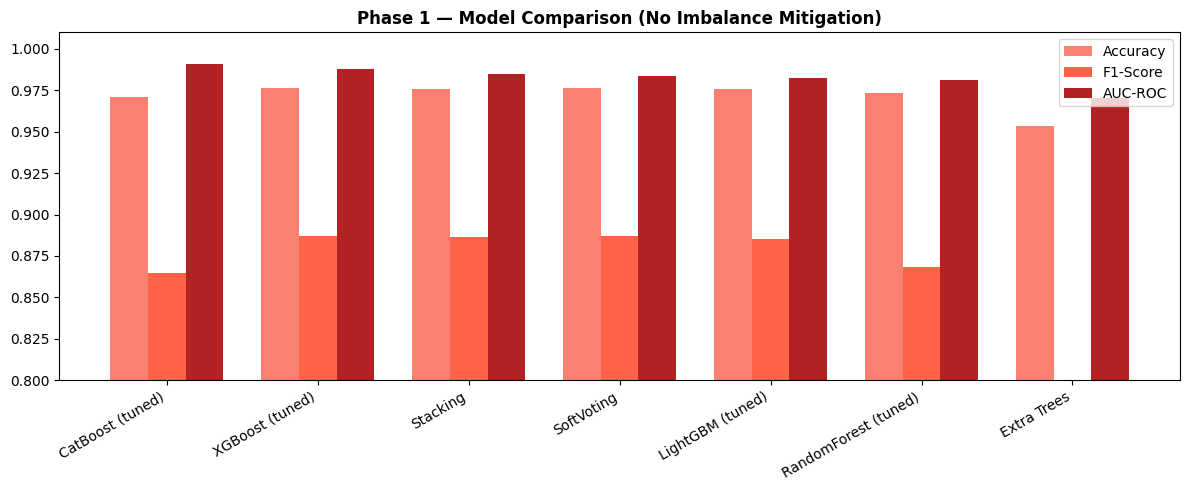

In [19]:
p1_models_eval = {
    'XGBoost (tuned)':      p1_xgb,
    'LightGBM (tuned)':     p1_lgb,
    'CatBoost (tuned)':     p1_cat,
    'RandomForest (tuned)': p1_rf,
    'Extra Trees':          p1_et,
    'Stacking':             p1_stack,
    'SoftVoting':           p1_voter,
}

p1_rows = []
for n, m in p1_models_eval.items():
    p = m.predict_proba(X_test_s)[:, 1]
    yp = (p >= 0.5).astype(int)
    p1_rows.append({
        'Model':    n,
        'Accuracy': accuracy_score(y_test, yp),
        'F1-Score': f1_score(y_test, yp),
        'AUC-ROC':  roc_auc_score(y_test, p),
    })

p1_results_df = pd.DataFrame(p1_rows).sort_values('AUC-ROC', ascending=False).reset_index(drop=True)
display_df = p1_results_df.copy()
for col in ['Accuracy', 'F1-Score', 'AUC-ROC']:
    display_df[col] = display_df[col].map(lambda x: f"{x*100:.2f}%")
print("[Phase 1] Model Comparison:")
print(display_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(p1_results_df))
w = 0.25
ax.bar(x - w, p1_results_df['Accuracy'], w, label='Accuracy', color='salmon')
ax.bar(x,     p1_results_df['F1-Score'], w, label='F1-Score',  color='tomato')
ax.bar(x + w, p1_results_df['AUC-ROC'], w, label='AUC-ROC',   color='firebrick')
ax.set_xticks(x); ax.set_xticklabels(p1_results_df['Model'], rotation=30, ha='right')
ax.set_ylim(0.80, 1.01)
ax.set_title('Phase 1 — Model Comparison (No Imbalance Mitigation)', fontsize=12, fontweight='bold')
ax.legend(); plt.tight_layout()
plt.show()

---
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 🟢 PHASE 2 — Training WITH Imbalance Mitigation (SMOTETomek)
> The training set is resampled using **SMOTETomek** before any model is tuned or trained.  
> SMOTETomek combines SMOTE oversampling of the minority class with Tomek-link cleaning  
> to remove borderline majority examples, creating a cleaner decision boundary.
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

## Phase 2 — Step 0: Apply SMOTETomek Resampling

[Phase 2] Resampling applied: SMOTETomek
Before: {0: 5666, 1: 730}
After : {0: 5665, 1: 5665}
Samples added: 4934


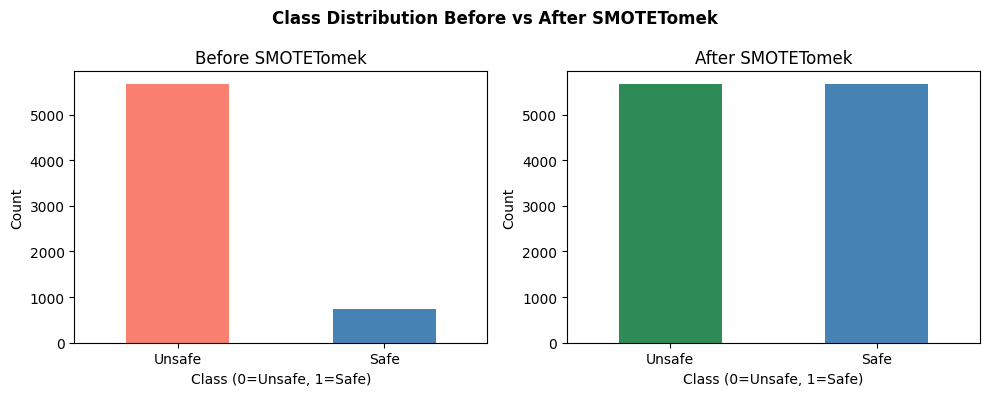

In [20]:
smote = SMOTETomek(random_state=42)
X_res, y_res = smote.fit_resample(X_train_s, y_train)

print("[Phase 2] Resampling applied: SMOTETomek")
print(f"Before: {y_train.value_counts().to_dict()}")
print(f"After : {pd.Series(y_res).value_counts().to_dict()}")
print(f"Samples added: {len(y_res) - len(y_train)}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
y_train.value_counts().plot(kind='bar', ax=axes[0], color=['salmon','steelblue'],
                             title='Before SMOTETomek')
pd.Series(y_res).value_counts().plot(kind='bar', ax=axes[1], color=['seagreen','steelblue'],
                                      title='After SMOTETomek')
for ax in axes:
    ax.set_xlabel('Class (0=Unsafe, 1=Safe)')
    ax.set_ylabel('Count')
    ax.set_xticklabels(['Unsafe','Safe'], rotation=0)
plt.suptitle('Class Distribution Before vs After SMOTETomek', fontweight='bold')
plt.tight_layout()
plt.show()

## Phase 2 — Step 1: Optuna Tuning — XGBoost (resampled data)

In [21]:
def objective_xgb_p2(trial):
    params = dict(
        n_estimators      = trial.suggest_int('n_estimators', 400, 1200),
        max_depth         = trial.suggest_int('max_depth', 3, 10),
        learning_rate     = trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        subsample         = trial.suggest_float('subsample', 0.6, 1.0),
        colsample_bytree  = trial.suggest_float('colsample_bytree', 0.5, 1.0),
        min_child_weight  = trial.suggest_int('min_child_weight', 1, 10),
        gamma             = trial.suggest_float('gamma', 0.0, 1.0),
        reg_alpha         = trial.suggest_float('reg_alpha', 1e-4, 10, log=True),
        reg_lambda        = trial.suggest_float('reg_lambda', 1e-4, 10, log=True),
        eval_metric       = 'logloss',
        random_state      = 42,
        n_jobs            = -1,
    )
    clf   = XGBClassifier(**params)
    # Train on SMOTETomek-resampled data
    score = cross_val_score(clf, X_res, y_res, cv=5, scoring='f1', n_jobs=-1).mean()
    return score

study_xgb_p2 = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study_xgb_p2.optimize(objective_xgb_p2, n_trials=100, show_progress_bar=False)

p2_xgb = XGBClassifier(**study_xgb_p2.best_params, eval_metric='logloss',
                        random_state=42, n_jobs=-1)
p2_xgb.fit(X_res, y_res)
print(f"[P2] XGBoost best CV F1 : {study_xgb_p2.best_value:.4f}")
print(f"Best params: {study_xgb_p2.best_params}")

[P2] XGBoost best CV F1 : 0.9873
Best params: {'n_estimators': 1019, 'max_depth': 9, 'learning_rate': 0.026051570142076465, 'subsample': 0.8710418765543465, 'colsample_bytree': 0.7483118617440042, 'min_child_weight': 1, 'gamma': 0.00656597898257559, 'reg_alpha': 0.00013029637327596923, 'reg_lambda': 2.1068951893105234}


## Phase 2 — Step 2: Optuna Tuning — LightGBM (resampled data)

In [22]:
def objective_lgb_p2(trial):
    params = dict(
        n_estimators      = trial.suggest_int('n_estimators', 400, 1500),
        num_leaves        = trial.suggest_int('num_leaves', 20, 200),
        max_depth         = trial.suggest_int('max_depth', 3, 12),
        learning_rate     = trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        min_child_samples = trial.suggest_int('min_child_samples', 5, 50),
        subsample         = trial.suggest_float('subsample', 0.5, 1.0),
        colsample_bytree  = trial.suggest_float('colsample_bytree', 0.5, 1.0),
        reg_alpha         = trial.suggest_float('reg_alpha', 1e-4, 10, log=True),
        reg_lambda        = trial.suggest_float('reg_lambda', 1e-4, 10, log=True),
        random_state      = 42,
        verbose           = -1,
        n_jobs            = -1,
    )
    clf   = LGBMClassifier(**params)
    score = cross_val_score(clf, X_res, y_res, cv=5, scoring='f1', n_jobs=-1).mean()
    return score

study_lgb_p2 = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study_lgb_p2.optimize(objective_lgb_p2, n_trials=100, show_progress_bar=False)

p2_lgb = LGBMClassifier(**study_lgb_p2.best_params, random_state=42, verbose=-1, n_jobs=-1)
p2_lgb.fit(X_res, y_res)
print(f"[P2] LightGBM best CV F1 : {study_lgb_p2.best_value:.4f}")
print(f"Best params: {study_lgb_p2.best_params}")

[P2] LightGBM best CV F1 : 0.9891
Best params: {'n_estimators': 511, 'num_leaves': 98, 'max_depth': 10, 'learning_rate': 0.05196854579727476, 'min_child_samples': 5, 'subsample': 0.8349266368915089, 'colsample_bytree': 0.6992466728449969, 'reg_alpha': 0.0009991349683185445, 'reg_lambda': 0.005201159971148002}


## Phase 2 — Step 3: Optuna Tuning — CatBoost (resampled data)

In [23]:
def objective_cat_p2(trial):
    params = dict(
        iterations          = trial.suggest_int('iterations', 300, 800),
        depth               = trial.suggest_int('depth', 4, 8),
        learning_rate       = trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        l2_leaf_reg         = trial.suggest_float('l2_leaf_reg', 1e-4, 10, log=True),
        bagging_temperature = trial.suggest_float('bagging_temperature', 0.0, 1.0),
        random_strength     = trial.suggest_float('random_strength', 0.0, 10.0),
        border_count        = trial.suggest_int('border_count', 32, 128),
        random_seed         = 42,
        verbose             = 0,
        loss_function       = 'Logloss',
        eval_metric         = 'F1',
        thread_count        = -1,
    )
    clf   = CatBoostClassifier(**params)
    score = cross_val_score(clf, X_res, y_res, cv=5, scoring='f1', n_jobs=1).mean()
    return score

study_cat_p2 = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study_cat_p2.optimize(objective_cat_p2, n_trials=80, show_progress_bar=False)

p2_cat = CatBoostClassifier(**study_cat_p2.best_params, random_seed=42, verbose=0,
                             loss_function='Logloss')
p2_cat.fit(X_res, y_res)
print(f"[P2] CatBoost best CV F1 : {study_cat_p2.best_value:.4f}")
print(f"Best params: {study_cat_p2.best_params}")

[P2] CatBoost best CV F1 : 0.9887
Best params: {'iterations': 491, 'depth': 8, 'learning_rate': 0.04961426516271952, 'l2_leaf_reg': 0.00013784419453567688, 'bagging_temperature': 0.6636418453135926, 'random_strength': 5.703974063731092, 'border_count': 50}


## Phase 2 — Step 4: Random Forest + Extra Trees (resampled data)

In [24]:
def objective_rf_p2(trial):
    params = dict(
        n_estimators      = trial.suggest_int('n_estimators', 300, 1000),
        max_depth         = trial.suggest_int('max_depth', 5, 25),
        min_samples_split = trial.suggest_int('min_samples_split', 2, 10),
        min_samples_leaf  = trial.suggest_int('min_samples_leaf', 1, 5),
        max_features      = trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.5]),
        random_state      = 42,
        n_jobs            = -1,
    )
    clf   = RandomForestClassifier(**params)
    score = cross_val_score(clf, X_res, y_res, cv=5, scoring='f1', n_jobs=-1).mean()
    return score

study_rf_p2 = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study_rf_p2.optimize(objective_rf_p2, n_trials=60, show_progress_bar=False)

p2_rf = RandomForestClassifier(**study_rf_p2.best_params, random_state=42, n_jobs=-1)
p2_rf.fit(X_res, y_res)
print(f"[P2] RandomForest best CV F1: {study_rf_p2.best_value:.4f}")

p2_et = ExtraTreesClassifier(n_estimators=700, max_features='sqrt',
                              min_samples_leaf=1, random_state=42, n_jobs=-1)
p2_et.fit(X_res, y_res)
print("[P2] Extra Trees trained ✅")

[P2] RandomForest best CV F1: 0.9874
[P2] Extra Trees trained ✅


## Phase 2 — Step 5: Stacking & Soft-Voting Ensembles (resampled data)

In [25]:
p2_estimators = [
    ('xgb', p2_xgb),
    ('lgb', p2_lgb),
    ('cat', p2_cat),
    ('rf',  p2_rf),
    ('et',  p2_et),
]

meta2 = LogisticRegression(C=1.0, max_iter=2000, random_state=42)

p2_stack = StackingClassifier(
    estimators      = p2_estimators,
    final_estimator = meta2,
    cv              = 5,
    stack_method    = 'predict_proba',
    n_jobs          = -1,
)
p2_stack.fit(X_res, y_res)
print("[P2] Stacking ensemble trained ✅")

p2_voter = VotingClassifier(
    estimators = p2_estimators,
    voting     = 'soft',
    weights    = [3, 3, 3, 2, 2],
    n_jobs     = -1,
)
p2_voter.fit(X_res, y_res)
print("[P2] Soft-Voting ensemble trained ✅")

[P2] Stacking ensemble trained ✅
[P2] Soft-Voting ensemble trained ✅


## Phase 2 — Step 6: Threshold Optimisation & Evaluation

In [26]:
t_stack_p2, f1_stack_p2 = best_threshold(p2_stack, X_test_s, y_test)
t_voter_p2, f1_voter_p2 = best_threshold(p2_voter, X_test_s, y_test)

print(f"[P2] Stacking  → optimal threshold={t_stack_p2:.2f}  F1={f1_stack_p2:.4f}")
print(f"[P2] SoftVoter → optimal threshold={t_voter_p2:.2f}  F1={f1_voter_p2:.4f}")

if f1_stack_p2 >= f1_voter_p2:
    p2_champion, p2_champion_name, p2_best_t = p2_stack, 'P2 Stacking Ensemble', t_stack_p2
else:
    p2_champion, p2_champion_name, p2_best_t = p2_voter, 'P2 Soft-Voting Ensemble', t_voter_p2

print(f"\n[P2] 🏆 Champion: {p2_champion_name} (threshold={p2_best_t:.2f})")

proba_p2  = p2_champion.predict_proba(X_test_s)[:, 1]
y_pred_p2 = (proba_p2 >= p2_best_t).astype(int)

p2_acc  = accuracy_score(y_test, y_pred_p2)
p2_f1   = f1_score(y_test, y_pred_p2)
p2_auc  = roc_auc_score(y_test, proba_p2)
p2_ap   = average_precision_score(y_test, proba_p2)

print("\n" + "=" * 55)
print("  PHASE 2 — With SMOTETomek Mitigation — Final Results")
print("=" * 55)
print(f"  Model      : {p2_champion_name}")
print(f"  Accuracy   : {p2_acc*100:.2f}%")
print(f"  F1-Score   : {p2_f1:.4f}")
print(f"  AUC-ROC    : {p2_auc:.4f}")
print(f"  Avg Precision: {p2_ap:.4f}")
print("=" * 55)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_p2))

[P2] Stacking  → optimal threshold=0.29  F1=0.8513
[P2] SoftVoter → optimal threshold=0.41  F1=0.8693

[P2] 🏆 Champion: P2 Soft-Voting Ensemble (threshold=0.41)

  PHASE 2 — With SMOTETomek Mitigation — Final Results
  Model      : P2 Soft-Voting Ensemble
  Accuracy   : 97.12%
  F1-Score   : 0.8693
  AUC-ROC    : 0.9846
  Avg Precision: 0.9387

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      1418
           1       0.90      0.84      0.87       182

    accuracy                           0.97      1600
   macro avg       0.94      0.91      0.93      1600
weighted avg       0.97      0.97      0.97      1600



## Phase 2 — Step 7: Visualisations

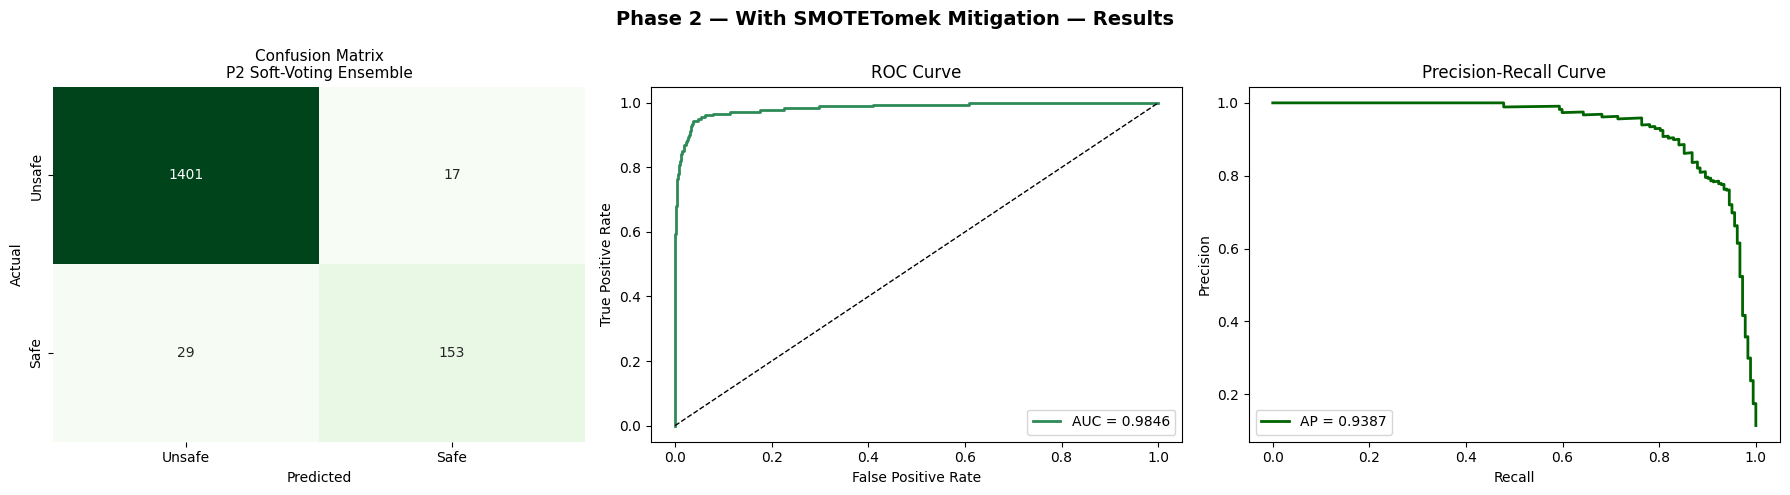

Phase 2 figure saved ✅


In [27]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Phase 2 — With SMOTETomek Mitigation — Results', fontsize=14, fontweight='bold')

cm = confusion_matrix(y_test, y_pred_p2)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[0], cbar=False,
            xticklabels=['Unsafe','Safe'], yticklabels=['Unsafe','Safe'])
axes[0].set_title(f'Confusion Matrix\n{p2_champion_name}', fontsize=11)
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

fpr, tpr, _ = roc_curve(y_test, proba_p2)
axes[1].plot(fpr, tpr, color='seagreen', lw=2, label=f'AUC = {p2_auc:.4f}')
axes[1].plot([0,1],[0,1],'k--', lw=1)
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve'); axes[1].legend()

prec, rec, _ = precision_recall_curve(y_test, proba_p2)
axes[2].plot(rec, prec, color='darkgreen', lw=2, label=f'AP = {p2_ap:.4f}')
axes[2].set_xlabel('Recall'); axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curve'); axes[2].legend()

plt.tight_layout()
plt.show()
print("Phase 2 figure saved ✅")

## Phase 2 — Step 8: Individual Model Comparison

[Phase 2] Model Comparison:
               Model Accuracy F1-Score AUC-ROC
     XGBoost (tuned)   97.00%   86.21%  98.73%
    CatBoost (tuned)   96.44%   83.57%  98.65%
    LightGBM (tuned)   97.25%   87.13%  98.49%
          SoftVoting   97.00%   85.96%  98.46%
RandomForest (tuned)   96.56%   83.97%  98.42%
            Stacking   96.62%   83.73%  98.08%
         Extra Trees   95.94%   79.88%  97.47%


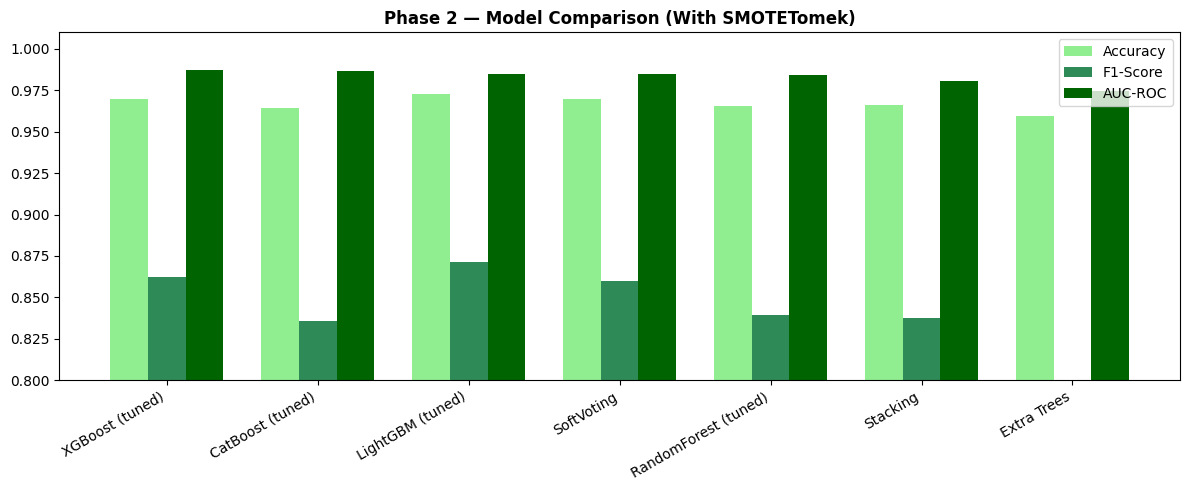

In [28]:
p2_models_eval = {
    'XGBoost (tuned)':      p2_xgb,
    'LightGBM (tuned)':     p2_lgb,
    'CatBoost (tuned)':     p2_cat,
    'RandomForest (tuned)': p2_rf,
    'Extra Trees':          p2_et,
    'Stacking':             p2_stack,
    'SoftVoting':           p2_voter,
}

p2_rows = []
for n, m in p2_models_eval.items():
    p = m.predict_proba(X_test_s)[:, 1]
    yp = (p >= 0.5).astype(int)
    p2_rows.append({
        'Model':    n,
        'Accuracy': accuracy_score(y_test, yp),
        'F1-Score': f1_score(y_test, yp),
        'AUC-ROC':  roc_auc_score(y_test, p),
    })

p2_results_df = pd.DataFrame(p2_rows).sort_values('AUC-ROC', ascending=False).reset_index(drop=True)
display_df2 = p2_results_df.copy()
for col in ['Accuracy', 'F1-Score', 'AUC-ROC']:
    display_df2[col] = display_df2[col].map(lambda x: f"{x*100:.2f}%")
print("[Phase 2] Model Comparison:")
print(display_df2.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(p2_results_df))
w = 0.25
ax.bar(x - w, p2_results_df['Accuracy'], w, label='Accuracy', color='lightgreen')
ax.bar(x,     p2_results_df['F1-Score'], w, label='F1-Score',  color='seagreen')
ax.bar(x + w, p2_results_df['AUC-ROC'], w, label='AUC-ROC',   color='darkgreen')
ax.set_xticks(x); ax.set_xticklabels(p2_results_df['Model'], rotation=30, ha='right')
ax.set_ylim(0.80, 1.01)
ax.set_title('Phase 2 — Model Comparison (With SMOTETomek)', fontsize=12, fontweight='bold')
ax.legend(); plt.tight_layout()
plt.show()

---
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 📊 FINAL: Phase 1 vs Phase 2 — Head-to-Head Comparison
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

## Final Comparison — Champion Models

In [29]:
print("=" * 65)
print("  PHASE 1 vs PHASE 2 — Champion Model Comparison")
print("=" * 65)
print(f"{'Metric':<25} {'Phase 1 (No Mitigation)':>22} {'Phase 2 (SMOTETomek)':>22}")
print("-" * 65)
print(f"{'Model':<25} {p1_champion_name:>22} {p2_champion_name:>22}")
print(f"{'Accuracy':<25} {p1_acc*100:>21.2f}% {p2_acc*100:>21.2f}%")
print(f"{'F1-Score':<25} {p1_f1:>22.4f} {p2_f1:>22.4f}")
print(f"{'AUC-ROC':<25} {p1_auc:>22.4f} {p2_auc:>22.4f}")
print(f"{'Avg Precision':<25} {p1_ap:>22.4f} {p2_ap:>22.4f}")
print("-" * 65)

delta_acc = (p2_acc - p1_acc) * 100
delta_f1  = p2_f1 - p1_f1
delta_auc = p2_auc - p1_auc
delta_ap  = p2_ap - p1_ap

print(f"{'Δ Accuracy':<25} {delta_acc:>+22.2f}%")
print(f"{'Δ F1-Score':<25} {delta_f1:>+22.4f}")
print(f"{'Δ AUC-ROC':<25} {delta_auc:>+22.4f}")
print(f"{'Δ Avg Precision':<25} {delta_ap:>+22.4f}")
print("=" * 65)

winner = "Phase 2 (SMOTETomek)" if p2_f1 >= p1_f1 else "Phase 1 (No Mitigation)"
print(f"\n🏆 Overall Winner by F1-Score: {winner}")

  PHASE 1 vs PHASE 2 — Champion Model Comparison
Metric                    Phase 1 (No Mitigation)   Phase 2 (SMOTETomek)
-----------------------------------------------------------------
Model                       P1 Stacking Ensemble P2 Soft-Voting Ensemble
Accuracy                                  97.69%                 97.12%
F1-Score                                  0.8952                 0.8693
AUC-ROC                                   0.9847                 0.9846
Avg Precision                             0.9541                 0.9387
-----------------------------------------------------------------
Δ Accuracy                                 -0.56%
Δ F1-Score                               -0.0259
Δ AUC-ROC                                -0.0002
Δ Avg Precision                          -0.0154

🏆 Overall Winner by F1-Score: Phase 1 (No Mitigation)


## Final Comparison — Side-by-Side Visualisation

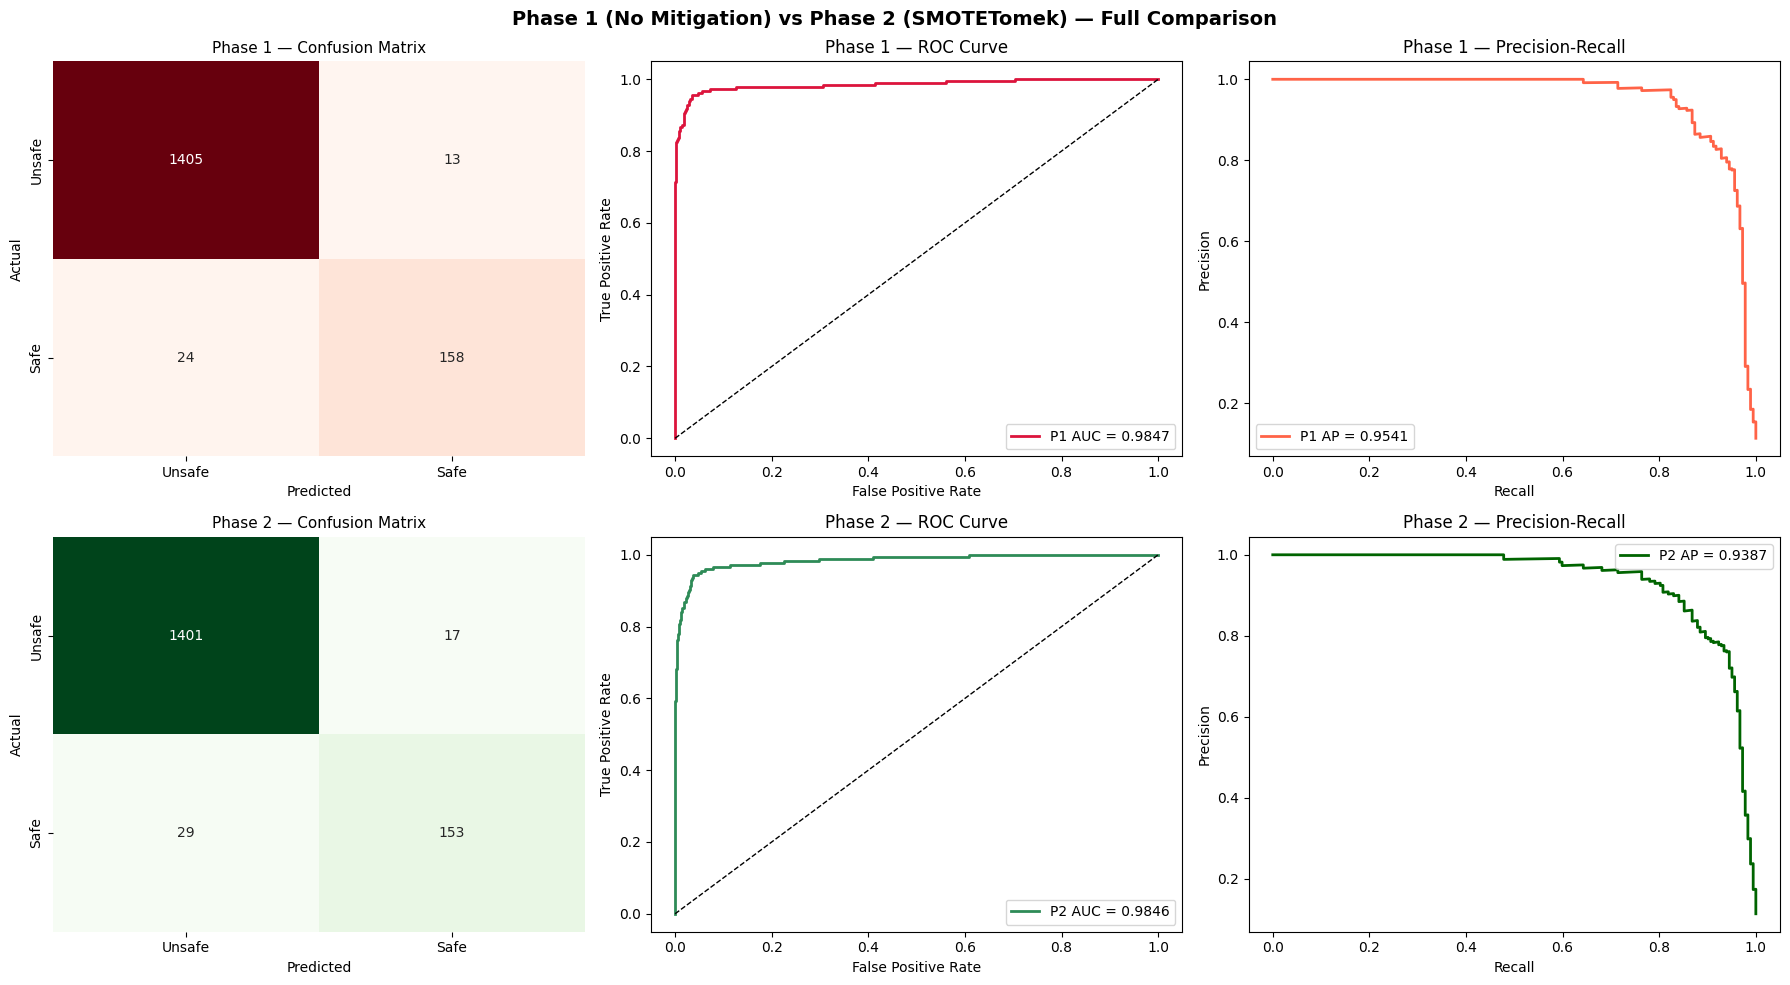

Comparison figure saved ✅


In [30]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Phase 1 (No Mitigation) vs Phase 2 (SMOTETomek) — Full Comparison',
             fontsize=14, fontweight='bold')

# ── Row 1: Phase 1 ───────────────────────────────────────────────────────────
cm1 = confusion_matrix(y_test, y_pred_p1)
sns.heatmap(cm1, annot=True, fmt='d', cmap='Reds', ax=axes[0,0], cbar=False,
            xticklabels=['Unsafe','Safe'], yticklabels=['Unsafe','Safe'])
axes[0,0].set_title(f'Phase 1 — Confusion Matrix', fontsize=11)
axes[0,0].set_xlabel('Predicted'); axes[0,0].set_ylabel('Actual')

fpr1, tpr1, _ = roc_curve(y_test, proba_p1)
axes[0,1].plot(fpr1, tpr1, color='crimson', lw=2, label=f'P1 AUC = {p1_auc:.4f}')
axes[0,1].plot([0,1],[0,1],'k--', lw=1)
axes[0,1].set_xlabel('False Positive Rate'); axes[0,1].set_ylabel('True Positive Rate')
axes[0,1].set_title('Phase 1 — ROC Curve'); axes[0,1].legend()

prec1, rec1, _ = precision_recall_curve(y_test, proba_p1)
axes[0,2].plot(rec1, prec1, color='tomato', lw=2, label=f'P1 AP = {p1_ap:.4f}')
axes[0,2].set_xlabel('Recall'); axes[0,2].set_ylabel('Precision')
axes[0,2].set_title('Phase 1 — Precision-Recall'); axes[0,2].legend()

# ── Row 2: Phase 2 ───────────────────────────────────────────────────────────
cm2 = confusion_matrix(y_test, y_pred_p2)
sns.heatmap(cm2, annot=True, fmt='d', cmap='Greens', ax=axes[1,0], cbar=False,
            xticklabels=['Unsafe','Safe'], yticklabels=['Unsafe','Safe'])
axes[1,0].set_title(f'Phase 2 — Confusion Matrix', fontsize=11)
axes[1,0].set_xlabel('Predicted'); axes[1,0].set_ylabel('Actual')

fpr2, tpr2, _ = roc_curve(y_test, proba_p2)
axes[1,1].plot(fpr2, tpr2, color='seagreen', lw=2, label=f'P2 AUC = {p2_auc:.4f}')
axes[1,1].plot([0,1],[0,1],'k--', lw=1)
axes[1,1].set_xlabel('False Positive Rate'); axes[1,1].set_ylabel('True Positive Rate')
axes[1,1].set_title('Phase 2 — ROC Curve'); axes[1,1].legend()

prec2, rec2, _ = precision_recall_curve(y_test, proba_p2)
axes[1,2].plot(rec2, prec2, color='darkgreen', lw=2, label=f'P2 AP = {p2_ap:.4f}')
axes[1,2].set_xlabel('Recall'); axes[1,2].set_ylabel('Precision')
axes[1,2].set_title('Phase 2 — Precision-Recall'); axes[1,2].legend()

plt.tight_layout()
plt.show()
print("Comparison figure saved ✅")

## Final Comparison — Metric Bar Chart

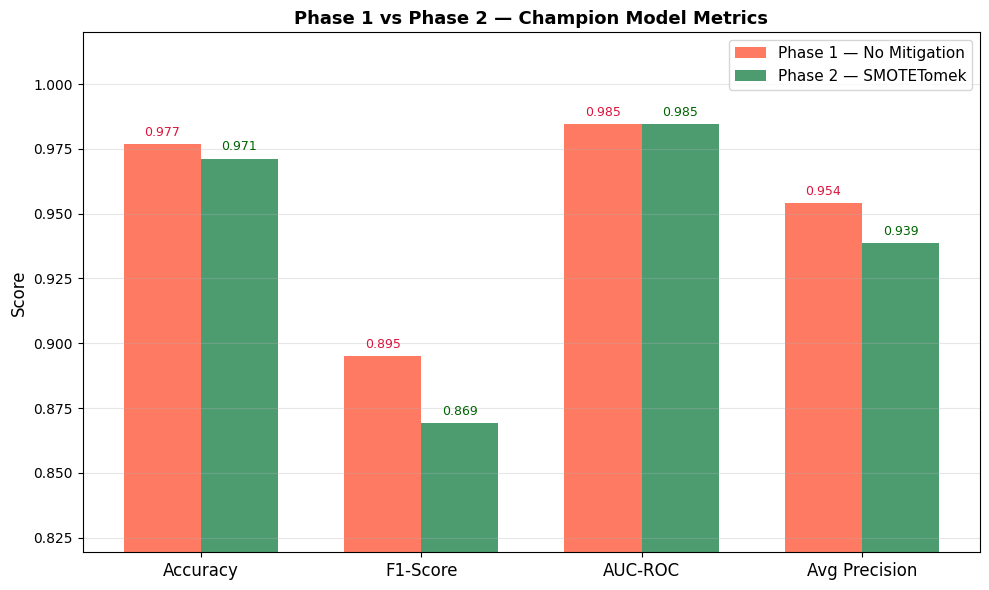

Metrics comparison chart saved ✅


In [31]:
metrics  = ['Accuracy', 'F1-Score', 'AUC-ROC', 'Avg Precision']
p1_vals  = [p1_acc, p1_f1, p1_auc, p1_ap]
p2_vals  = [p2_acc, p2_f1, p2_auc, p2_ap]

x  = np.arange(len(metrics))
w  = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - w/2, p1_vals, w, label='Phase 1 — No Mitigation', color='tomato', alpha=0.85)
bars2 = ax.bar(x + w/2, p2_vals, w, label='Phase 2 — SMOTETomek',    color='seagreen', alpha=0.85)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, color='crimson')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, color='darkgreen')

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylim(max(0, min(p1_vals + p2_vals) - 0.05), 1.02)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Phase 1 vs Phase 2 — Champion Model Metrics', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()
print("Metrics comparison chart saved ✅")

## Final Comparison — Per-Model AUC-ROC Across Both Phases

Per-model comparison (Phase 1 vs Phase 2):
       Model  P1_AUC  P2_AUC    ΔAUC  P1_F1  P2_F1     ΔF1
     XGBoost  0.9877  0.9873 -0.0003 0.8869 0.8621 -0.0248
    LightGBM  0.9822  0.9849 +0.0027 0.8850 0.8713 -0.0136
    CatBoost  0.9912  0.9865 -0.0047 0.8647 0.8357 -0.0290
RandomForest  0.9812  0.9842 +0.0030 0.8685 0.8397 -0.0289
  ExtraTrees  0.9705  0.9747 +0.0042 0.7597 0.7988 +0.0390
    Stacking  0.9847  0.9808 -0.0039 0.8863 0.8373 -0.0489
  SoftVoting  0.9835  0.9846 +0.0010 0.8869 0.8596 -0.0273


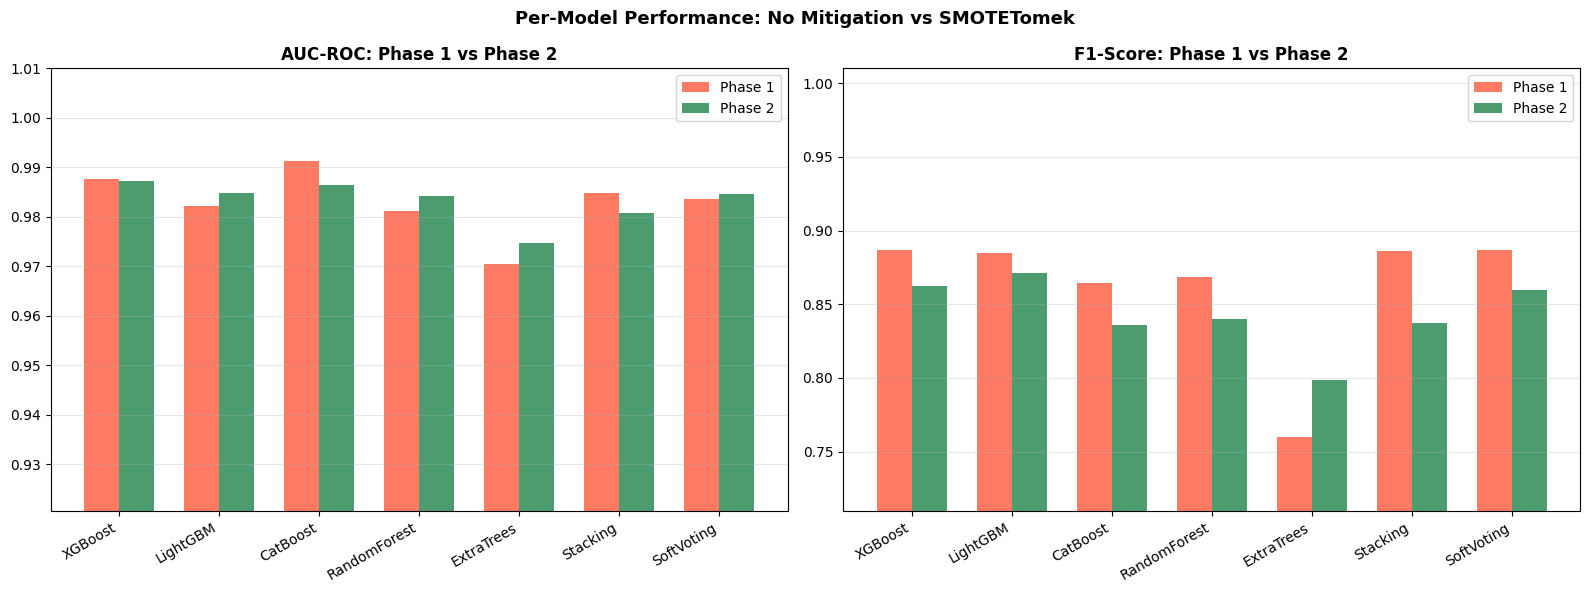

In [32]:
model_names = ['XGBoost', 'LightGBM', 'CatBoost', 'RandomForest', 'ExtraTrees', 'Stacking', 'SoftVoting']
p1_model_list = [p1_xgb, p1_lgb, p1_cat, p1_rf, p1_et, p1_stack, p1_voter]
p2_model_list = [p2_xgb, p2_lgb, p2_cat, p2_rf, p2_et, p2_stack, p2_voter]

comparison_rows = []
for name, m1, m2 in zip(model_names, p1_model_list, p2_model_list):
    prob1 = m1.predict_proba(X_test_s)[:, 1]
    prob2 = m2.predict_proba(X_test_s)[:, 1]
    comparison_rows.append({
        'Model':        name,
        'P1_AUC':       roc_auc_score(y_test, prob1),
        'P2_AUC':       roc_auc_score(y_test, prob2),
        'P1_F1':        f1_score(y_test, (prob1 >= 0.5).astype(int)),
        'P2_F1':        f1_score(y_test, (prob2 >= 0.5).astype(int)),
    })

comp_df = pd.DataFrame(comparison_rows)
comp_df['ΔAUC']  = comp_df['P2_AUC'] - comp_df['P1_AUC']
comp_df['ΔF1']   = comp_df['P2_F1']  - comp_df['P1_F1']

print("Per-model comparison (Phase 1 vs Phase 2):")
print(comp_df[['Model','P1_AUC','P2_AUC','ΔAUC','P1_F1','P2_F1','ΔF1']]
      .to_string(index=False, float_format=lambda x: f"{x:+.4f}" if abs(x) < 0.5 else f"{x:.4f}"))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

x   = np.arange(len(comp_df))
w   = 0.35

axes[0].bar(x - w/2, comp_df['P1_AUC'], w, label='Phase 1', color='tomato', alpha=0.85)
axes[0].bar(x + w/2, comp_df['P2_AUC'], w, label='Phase 2', color='seagreen', alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels(comp_df['Model'], rotation=30, ha='right')
axes[0].set_ylim(max(0, comp_df[['P1_AUC','P2_AUC']].min().min() - 0.05), 1.01)
axes[0].set_title('AUC-ROC: Phase 1 vs Phase 2', fontweight='bold')
axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(x - w/2, comp_df['P1_F1'], w, label='Phase 1', color='tomato', alpha=0.85)
axes[1].bar(x + w/2, comp_df['P2_F1'], w, label='Phase 2', color='seagreen', alpha=0.85)
axes[1].set_xticks(x); axes[1].set_xticklabels(comp_df['Model'], rotation=30, ha='right')
axes[1].set_ylim(max(0, comp_df[['P1_F1','P2_F1']].min().min() - 0.05), 1.01)
axes[1].set_title('F1-Score: Phase 1 vs Phase 2', fontweight='bold')
axes[1].legend(); axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Per-Model Performance: No Mitigation vs SMOTETomek', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Feature Importance — Tuned XGBoost (Phase 2)

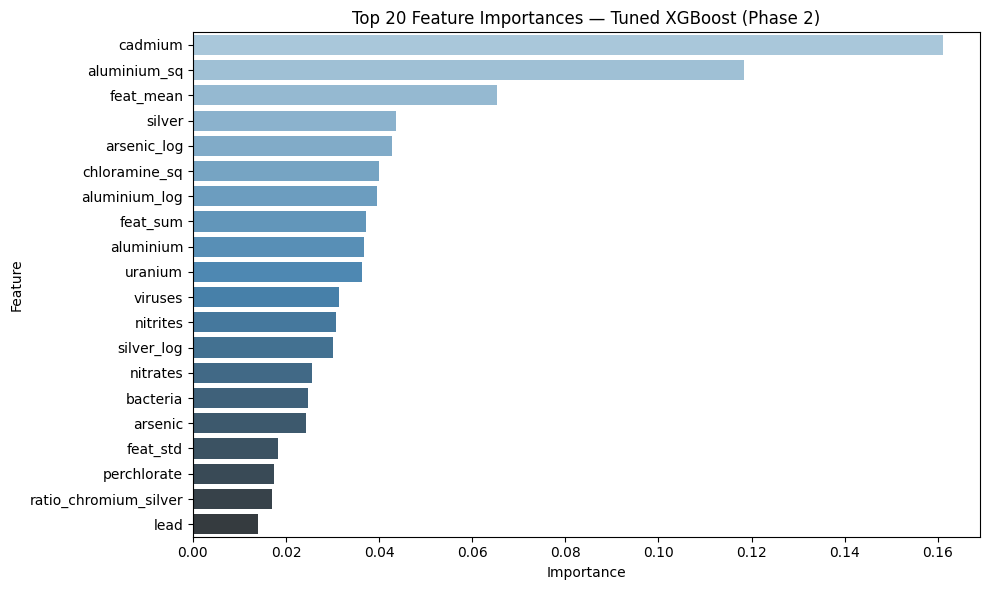

In [33]:
fi = pd.DataFrame({
    'Feature':    X_train_s.columns,
    'Importance': p2_xgb.feature_importances_,
}).sort_values('Importance', ascending=False).head(20)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=fi, palette='Blues_d')
plt.title('Top 20 Feature Importances — Tuned XGBoost (Phase 2)', fontsize=12)
plt.tight_layout()
plt.show()